# Budengyao Hopf Validation

This notebook first searches Hopf bifurcation points for the asymmetric kernel in `budengyao.pdf` by plotting `S_{n,k}(\varepsilon)`, then uses a detected critical `\varepsilon_*` in the FiPy simulation.


In [1]:
import sys
import subprocess
import importlib


def _pip_install(pkg: str) -> None:
    print(f"Installing {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])


def ensure_import(import_name: str, pip_name: str | None = None):
    if pip_name is None:
        pip_name = import_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        _pip_install(pip_name)
        return importlib.import_module(import_name)


np = ensure_import("numpy", "numpy")
plt = ensure_import("matplotlib.pyplot", "matplotlib")
root_scalar = ensure_import("scipy.optimize", "scipy").root_scalar
from IPython.display import display

fipy = ensure_import("fipy", "fipy")
from fipy import *

try:
    from tqdm.notebook import tqdm
except Exception:
    ensure_import("tqdm", "tqdm")
    from tqdm import tqdm

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("All packages are ready!")


All packages are ready!


In [2]:
# Shared model parameters
# Reaction term: f(u) = r1 * u * (1 - u)
d1 = 0.3
d2 = 1.5
r1 = 0.1
u_bar = 1.0
f_u = -r1

# Geometry and mode selection
L = np.pi
n_branch = 2       # mode used in the branch search
n_init = 2         # mode used in the simulation perturbation
mu_n = (n_branch * np.pi / L) ** 2

# Delay parameters
tau = 2.0

# Branch-search controls
k_values = [0, 1, 2]
epsilon_min = 0.05
epsilon_max = tau - 0.05
epsilon_samples = 300
omega_min = 0.05
omega_max = 12.0
omega_scan_points = 4000
root_index = 0     # choose the first positive omega branch for S_{n,k}

# Simulation controls
Nx = 101
dt = 0.01
Tend = 50.0
update_step = 200
steps = int(round(Tend / dt))

print(f"mu_n={mu_n:.4f}, tau={tau}, search eps in [{epsilon_min}, {epsilon_max}]")


mu_n=4.0000, tau=2.0, search eps in [0.05, 1.95]


## Branch Search

For each `\varepsilon`, we solve `G(\omega, \varepsilon)=0` for positive `\omega`, choose one branch `\omega_n(\varepsilon)`, and then plot `S_{n,k}(\varepsilon)=\varepsilon-(\theta_n(\varepsilon)+2k\pi)/\omega_n(\varepsilon)`. Zero crossings of `S_{n,k}` give critical values `\varepsilon_{n,k}`.


In [3]:
def G_budengyao(omega: float, epsilon: float, mu_n: float) -> float:
    drift = d1 * mu_n - f_u
    coupling = d2 * u_bar * mu_n
    term6 = epsilon * (tau - epsilon) * tau * omega**6 / (4.0 * coupling)
    term4 = epsilon * (tau - epsilon) * tau * drift**2 * omega**4 / (4.0 * coupling)
    term3 = epsilon * np.sin(omega * tau) * omega**3
    term2 = -drift * (tau - epsilon + epsilon * np.cos(omega * tau)) * omega**2
    term0 = (2.0 * coupling / tau) * (np.cos(omega * tau) - 1.0)
    return term6 + term4 + term3 + term2 + term0


def sin_target(omega: float, epsilon: float, mu_n: float) -> float:
    coupling = d2 * u_bar * mu_n
    return (
        epsilon * (tau - epsilon) * omega**3 / (2.0 * coupling)
        + epsilon * np.sin(omega * tau) / tau
    )


def cos_target(omega: float, epsilon: float, mu_n: float) -> float:
    coupling = d2 * u_bar * mu_n
    drift = d1 * mu_n - f_u
    return (
        (tau - epsilon) / tau
        + epsilon * np.cos(omega * tau) / tau
        - epsilon * (tau - epsilon) * drift * omega**2 / (2.0 * coupling)
    )


def positive_omega_roots(epsilon: float, mu_n: float) -> list[float]:
    grid = np.linspace(omega_min, omega_max, omega_scan_points)
    values = [G_budengyao(w, epsilon, mu_n) for w in grid]
    roots = []
    for left, right, f_left, f_right in zip(grid[:-1], grid[1:], values[:-1], values[1:]):
        if not np.isfinite(f_left) or not np.isfinite(f_right):
            continue
        if abs(f_left) < 1e-10:
            roots.append(left)
            continue
        if f_left * f_right > 0:
            continue
        try:
            solved = root_scalar(
                lambda w: G_budengyao(w, epsilon, mu_n),
                bracket=(left, right),
                method="brentq",
            )
        except ValueError:
            continue
        if solved.converged:
            roots.append(solved.root)
    roots = sorted(roots)

    unique_roots = []
    for root in roots:
        if not unique_roots or abs(root - unique_roots[-1]) > 1e-4:
            unique_roots.append(root)
    return unique_roots


def theta_from_branch(omega: float, epsilon: float, mu_n: float) -> float:
    sin_val = np.clip(sin_target(omega, epsilon, mu_n), -1.0, 1.0)
    cos_val = np.clip(cos_target(omega, epsilon, mu_n), -1.0, 1.0)
    return np.mod(np.arctan2(sin_val, cos_val), 2.0 * np.pi)


def find_branch_data(mu_n: float, k_values: list[int]):
    epsilon_grid = np.linspace(epsilon_min, epsilon_max, epsilon_samples)
    omega_branch = np.full_like(epsilon_grid, np.nan, dtype=float)
    theta_branch = np.full_like(epsilon_grid, np.nan, dtype=float)
    S_curves = {k: np.full_like(epsilon_grid, np.nan, dtype=float) for k in k_values}

    for idx, epsilon in enumerate(epsilon_grid):
        roots = positive_omega_roots(epsilon, mu_n)
        if len(roots) <= root_index:
            continue
        omega = roots[root_index]
        theta = theta_from_branch(omega, epsilon, mu_n)
        omega_branch[idx] = omega
        theta_branch[idx] = theta
        for k in k_values:
            S_curves[k][idx] = epsilon - (theta + 2.0 * k * np.pi) / omega

    return epsilon_grid, omega_branch, theta_branch, S_curves


def zero_crossings(x: np.ndarray, y: np.ndarray) -> list[float]:
    roots = []
    for x0, x1, y0, y1 in zip(x[:-1], x[1:], y[:-1], y[1:]):
        if np.isnan(y0) or np.isnan(y1):
            continue
        if abs(y0) < 1e-8:
            roots.append(x0)
            continue
        if y0 * y1 > 0:
            continue
        roots.append(x0 - y0 * (x1 - x0) / (y1 - y0))
    unique_roots = []
    for root in roots:
        if not unique_roots or abs(root - unique_roots[-1]) > 1e-4:
            unique_roots.append(root)
    return unique_roots


epsilon_grid, omega_branch, theta_branch, S_curves = find_branch_data(mu_n, k_values)
critical_eps = {k: zero_crossings(epsilon_grid, S_curves[k]) for k in k_values}

for k in k_values:
    print(f"k={k}: epsilon roots -> {critical_eps[k]}")


k=0: epsilon roots -> [0.44256923457031055]
k=1: epsilon roots -> []
k=2: epsilon roots -> []


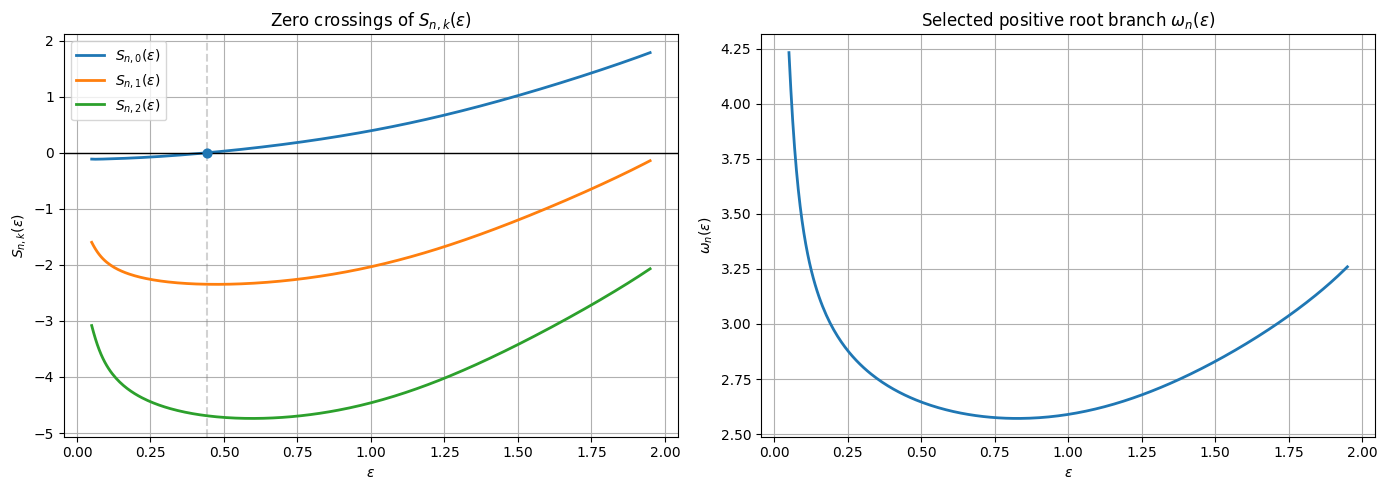

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for k in k_values:
    axes[0].plot(epsilon_grid, S_curves[k], linewidth=2, label=fr"$S_{{n,{k}}}(\epsilon)$")
    for eps_star in critical_eps[k]:
        axes[0].axvline(eps_star, color='gray', linestyle='--', alpha=0.35)
        axes[0].scatter(
            [eps_star],
            [0.0],
            s=40,
            zorder=3,
        )

axes[0].axhline(0.0, color='black', linewidth=1)
axes[0].set_xlabel(r"$\epsilon$")
axes[0].set_ylabel(r"$S_{n,k}(\epsilon)$")
axes[0].set_title(r"Zero crossings of $S_{n,k}(\epsilon)$")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epsilon_grid, omega_branch, color='tab:blue', linewidth=2)
axes[1].set_xlabel(r"$\epsilon$")
axes[1].set_ylabel(r"$\omega_n(\epsilon)$")
axes[1].set_title(r"Selected positive root branch $\omega_n(\epsilon)$")
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [5]:
# Pick a critical epsilon from the S_{n,k} plot.
# By default, use the first zero of k=0 if available.
if critical_eps[0]:
    epsilon = float(critical_eps[0][0])
else:
    epsilon = 0.442575

print(f"Selected epsilon for simulation: {epsilon:.6f}")


Selected epsilon for simulation: 0.442569


## Time-Domain Validation

The cells below reuse the original FiPy workflow and only replace the delay kernel by the asymmetric kernel `h_\varepsilon(s)` from `budengyao.pdf`.


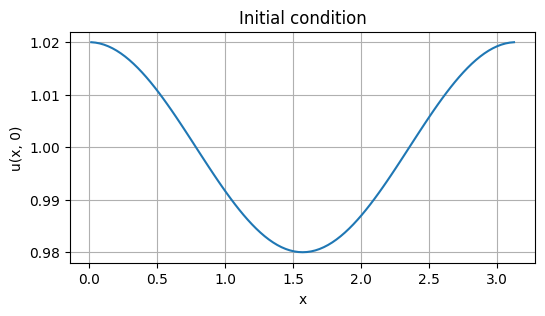

In [6]:
mesh = Grid1D(nx=Nx, Lx=L)
u = CellVariable(name="u", mesh=mesh, value=0.0, hasOld=True)
u_tau = CellVariable(name="u_tau", mesh=mesh, value=0.0)

x = mesh.cellCenters[0]
u.setValue(u_bar + 0.02 * np.cos(n_init * np.pi * x / L))
u.updateOld()

plt.figure(figsize=(6, 3))
plt.plot(x, u.value)
plt.title("Initial condition")
plt.xlabel("x")
plt.ylabel("u(x, 0)")
plt.grid(True)
plt.show()


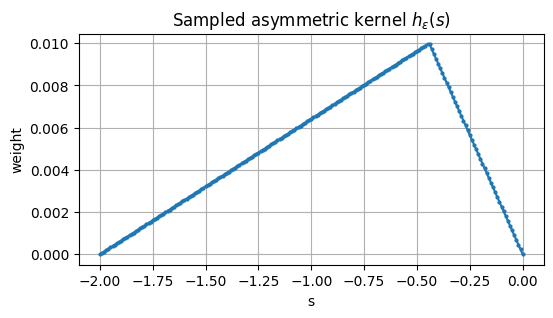

sum(h_weights) = 1.000000


In [7]:
history_steps = int(np.round(tau / dt)) + 1
if history_steps < 3:
    history_steps = 3
if history_steps % 2 == 0:
    history_steps += 1

s_vec = np.linspace(-tau, 0.0, history_steps)
h_weights = np.zeros(history_steps)
left_mask = (s_vec >= -tau) & (s_vec <= -epsilon)
right_mask = (s_vec >= -epsilon) & (s_vec <= 0.0)

h_weights[left_mask] = 2.0 * (s_vec[left_mask] + tau) / (tau * (tau - epsilon))
h_weights[right_mask] = -2.0 * s_vec[right_mask] / (tau * epsilon)

h_weights = np.clip(h_weights, 0.0, None)
h_weights /= h_weights.sum()

u_history_buf = np.zeros((history_steps, Nx))
for i in range(history_steps):
    u_history_buf[i, :] = u.value.copy()
buf_idx = 0

plt.figure(figsize=(6, 3))
plt.plot(s_vec, h_weights, marker='o', markersize=2)
plt.title(r"Sampled asymmetric kernel $h_\epsilon(s)$")
plt.xlabel("s")
plt.ylabel("weight")
plt.grid(True)
plt.show()
print(f"sum(h_weights) = {h_weights.sum():.6f}")


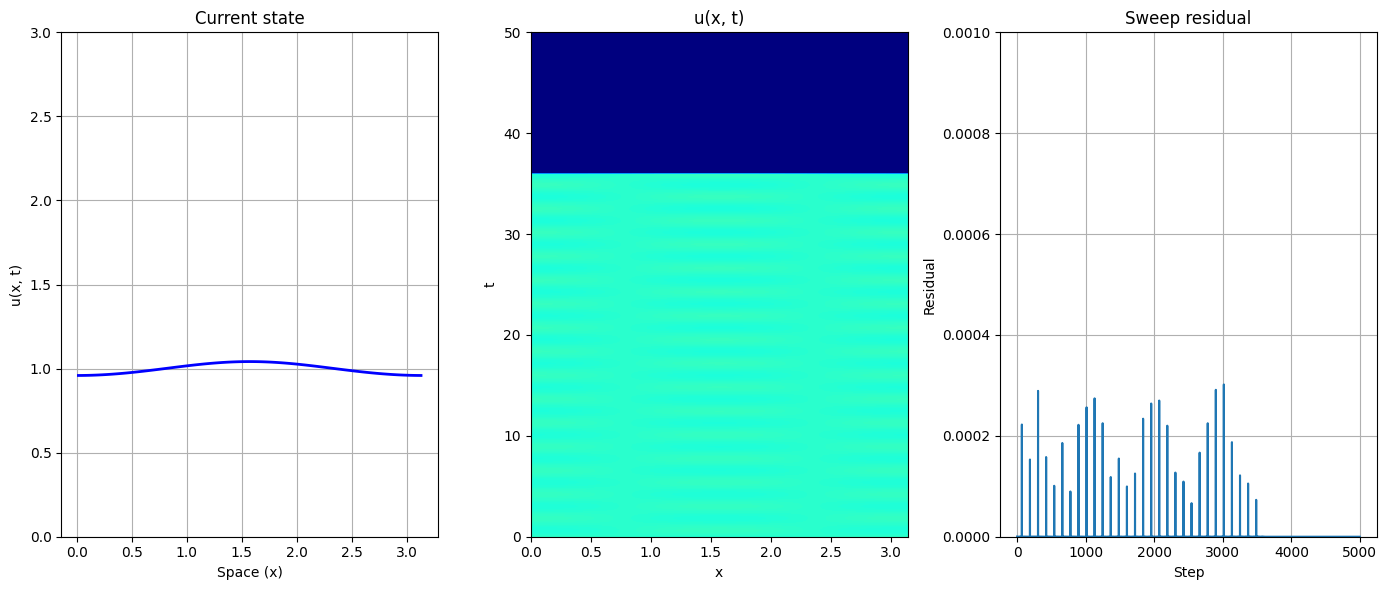

  0%|          | 0/5000 [00:00<?, ?it/s]

In [ ]:
velocity = d2 * u_tau.faceGrad
advection = UpwindConvectionTerm(coeff=velocity, var=u)
reaction_explicit = r1 * u
reaction_implicit = ImplicitSourceTerm(coeff=-r1 * u, var=u)
reaction = reaction_explicit + reaction_implicit
eq = (
    TransientTerm(var=u)
    == DiffusionTerm(coeff=d1, var=u) + advection + reaction
)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6))
line, = ax1.plot(x, u.value, 'b-', linewidth=2)
ax1.set_ylim(0, 3)
ax1.set_ylabel('u(x, t)')
ax1.set_xlabel('Space (x)')
ax1.set_title('Current state')
ax1.grid(True)

solution_matrix = np.zeros((steps, Nx))
solution_matrix[0, :] = u.value
heatmap = ax2.imshow(
    solution_matrix,
    aspect='auto',
    cmap='jet',
    vmin=0,
    vmax=2.5,
    extent=[0, L, 0, steps * dt],
    origin='lower',
)
ax2.set_xlabel('x')
ax2.set_ylabel('t')
ax2.set_title('u(x, t)')

residences = np.zeros((steps,))
resid_line, = ax3.plot(range(steps), residences)
ax3.set_ylim(0, 1e-3)
ax3.set_ylabel('Residual')
ax3.set_xlabel('Step')
ax3.set_title('Sweep residual')
ax3.grid(True)

plt.tight_layout()
try:
    obs_display = display(fig, display_id=True)
except Exception:
    obs_display = None
plt.close(fig)

pbar = tqdm(range(steps))
MAX_SWEEP = 500

for step in pbar:
    order = np.arange(buf_idx, buf_idx + history_steps) % history_steps
    u_tau_val = np.dot(h_weights, u_history_buf[order])
    u_tau.setValue(u_tau_val)

    resid = 1e6
    cnt = 0
    last_resid = resid
    while resid > 1e-4 and cnt < MAX_SWEEP:
        resid = eq.sweep(var=u, dt=dt)
        cnt += 1
        if abs(resid - last_resid) < 1e-5:
            break
        last_resid = resid

    u_history_buf[buf_idx, :] = u.value.copy()
    buf_idx = (buf_idx + 1) % history_steps

    solution_matrix[step, :] = u.value
    residences[step] = resid
    u.updateOld()
    pbar.set_postfix({'Resid': f'{resid:2e}'})

    if step % update_step == 0 or step == steps - 1:
        line.set_ydata(u.value)
        heatmap.set_data(solution_matrix)
        heatmap.set_extent([0, L, 0, steps * dt])
        ax2.set_xlim(0, L)
        ax2.set_ylim(0, steps * dt)
        resid_line.set_ydata(residences)
        if obs_display is not None:
            obs_display.update(fig)
        else:
            plt.pause(0.001)


In [ ]:
fig.canvas.draw()
bbox = ax2.get_tightbbox(fig.canvas.get_renderer())
bbox = bbox.transformed(fig.dpi_scale_trans.inverted())
fig.savefig("ax2_heatmap_budengyao.eps", bbox_inches=bbox, format="eps")

plt.close(fig)

fig2, ax_final = plt.subplots(1, 1, figsize=(6, 6))
final_heatmap = ax_final.imshow(
    solution_matrix,
    aspect='auto',
    cmap='jet',
    vmin=0,
    vmax=2.5,
    extent=[0, L, 0, steps * dt],
    origin='lower',
)
ax_final.set_xlabel('x')
ax_final.set_ylabel('t')
ax_final.set_title('u(x, t) with asymmetric kernel')
plt.colorbar(final_heatmap, ax=ax_final, label='Concentration u')
plt.show()
